In [1]:
import warnings
warnings.filterwarnings('ignore')

(Tutorial_Get_water_bridges)=
# get_water_bridges

*Observing simultaneous hydrogen bonds through one water.*

The method `two_hbonds_one_water` composes two observed hydrogen-bond branches. Choose the leg science explicitly; the default is Baker-Hubbard. This is the single-water path concept used by ProLIF and MDAnalysis, with MolSysMT atom-level identities and no claim of complete residue/network pipeline parity.

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

See {func}`molsysmt.interactions.water_bridges.get_water_bridges` for arguments, outputs and explicit failures.
:::

## Basic usage

Two carbonyl fragments mimic hydration at a ligand or protein interface. Controlled coordinates give two straight O-H-O branches and an evaluated empty middle frame; they are not an optimized binding pose.

In [2]:
import numpy as np
import molsysmt as msm
from rdkit import Chem
molsys = msm.convert(Chem.AddHs(Chem.MolFromSmiles('O.C=O.C=O')), to_form='molsysmt.MolSys')
xyz = np.zeros((3, 11, 3))
xyz[:,:,2] = np.arange(11) * 3 + 3
xyz[:,0] = [0,0,0]
xyz[:,5] = [.1,0,0]
xyz[:,6] = [0,.1,0]
xyz[:,2] = [.3,0,0]
xyz[:,4] = [0,.3,0]
xyz[1,4] += 2
molsys.structures.append(coordinates=msm.pyunitwizard.quantity(xyz, 'nm'))
analysis = msm.interactions.water_bridges.get_water_bridges(molsys, pbc=False)
print('Observations:', analysis.n_interactions, 'evaluated frames:', analysis.evaluated_structure_indices.tolist())

Observations: 2 evaluated frames: [0, 1, 2]


## Reading branch roles

Each path stores two directed D-H-A triples as six singleton roles. The shared water oxygen appears twice, preserving both branches. An unused water H is not an additional participant. Water may donate both branches, accept both, or donate one and accept one.

In [3]:
print(analysis.relation(0))
print(analysis.participant_atoms, analysis.measure_units)
print('Water incident:', analysis.query(atom_indices=[0], mode='incident').n_interactions)
print('Water alone internal:', analysis.query(atom_indices=[0], mode='internal').n_interactions)

{'interaction_type': 'water_bridge', 'participants': [{'role': 'leg_1_donor', 'atom_indices': array([0])}, {'role': 'leg_1_hydrogen', 'atom_indices': array([5])}, {'role': 'leg_1_acceptor', 'atom_indices': array([2])}, {'role': 'leg_2_donor', 'atom_indices': array([0])}, {'role': 'leg_2_hydrogen', 'atom_indices': array([6])}, {'role': 'leg_2_acceptor', 'atom_indices': array([4])}]}
[0 5 2 0 6 4] {'leg_1_donor_hydrogen_distance': 'nm', 'leg_1_donor_acceptor_distance': 'nm', 'leg_1_hydrogen_acceptor_distance': 'nm', 'leg_1_dha_angle': 'radians', 'leg_1_hda_angle': 'radians', 'leg_2_donor_hydrogen_distance': 'nm', 'leg_2_donor_acceptor_distance': 'nm', 'leg_2_hydrogen_acceptor_distance': 'nm', 'leg_2_dha_angle': 'radians', 'leg_2_hda_angle': 'radians'}
Water incident: 2
Water alone internal: 0


## Selecting all participants

Internal requires all actual leg atoms, including the mediator. An endpoint-only set needs incident. Between requires every participant in the union, with at least one in each disjoint selection; include water atoms explicitly. Queries do not silently create endpoint semantics.

In [4]:
actual = np.unique(analysis.participant_atoms)
for mode, first, second in [('internal',actual,None), ('incident',[2],None), ('between',[0],np.setdiff1d(actual,[0]))]:
    result = msm.interactions.water_bridges.get_water_bridges(molsys, selection=first, selection_2=second, selection_mode=mode, structure_indices=[2,0,2], pbc=False)
    print(mode, result.n_interactions, result.evaluated_structure_indices.tolist())
print('Endpoints-only internal:', msm.interactions.water_bridges.get_water_bridges(molsys, selection=[2,4], pbc=False).n_interactions)

internal 2 [0, 2]
incident 2 [0, 2]


between 2 [0, 2]


Endpoints-only internal: 0


## Choosing the science for each leg

Baker-Hubbard uses H-A <0.25 nm and D-H-A >120 degrees. Wernet-Nilsson uses its angular distance curve. The descriptive D-A/angle method can use the pinned SMARTS profile. Neither path identity nor geometry is inferred from a residue label. explicit_sites is unavailable in this wrapper.

In [5]:
for method, profile in [('baker_hubbard',None), ('wernet_nilsson',None), ('donor_acceptor_distance_angle','smarts_donor_acceptor')]:
    result = msm.interactions.water_bridges.get_water_bridges(molsys, hbond_method=method, hbond_profile=profile, pbc=False)
    print(method, result.n_interactions, result.parameters['hbond_profile'])
with msm.pyunitwizard.context(standard_units=['angstrom','degrees','ps','e']):
    result = msm.interactions.water_bridges.get_water_bridges(molsys, distance_threshold='2.5 angstrom', angle_threshold='120 degrees', pbc=False)
print(result.measure_units)

baker_hubbard 2 nitrogen_oxygen


wernet_nilsson 2 nitrogen_oxygen


donor_acceptor_distance_angle 2 smarts_donor_acceptor


{'leg_1_donor_hydrogen_distance': 'nm', 'leg_1_donor_acceptor_distance': 'nm', 'leg_1_hydrogen_acceptor_distance': 'nm', 'leg_1_dha_angle': 'radians', 'leg_1_hda_angle': 'radians', 'leg_2_donor_hydrogen_distance': 'nm', 'leg_2_donor_acceptor_distance': 'nm', 'leg_2_hydrogen_acceptor_distance': 'nm', 'leg_2_dha_angle': 'radians', 'leg_2_hda_angle': 'radians'}


## Inspecting structural observations

The two branches must exist in the same frame. Two observations in different frames are not a path. Alternative hydrogens and bifurcated legs remain distinct exact branch pairs; repeated queries do not duplicate them.

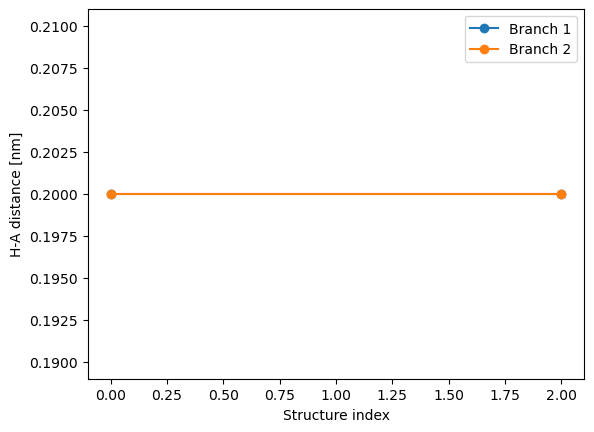

Evaluated empty: [1]


In [6]:
import matplotlib.pyplot as plt
for branch in (1,2):
    plt.plot(analysis.occurrence_structures, analysis.measurements[f'leg_{branch}_hydrogen_acceptor_distance'], 'o-', label=f'Branch {branch}')
plt.xlabel('Structure index'); plt.ylabel('H-A distance [nm]'); plt.legend(); plt.show()
print('Evaluated empty:', analysis.query(structure_indices=[1]).to_dict()['evaluated_structure_indices'])

## Retaining coherent periodic geometry

Each branch retains its observed geometry. The second is translated onto the first branch water-oxygen image, then the six roles are anchored on the first role. Conflicting images of a repeated atom raise. Image shifts reproduce observations; they do not reconstruct the whole molecule.

In [7]:
periodic = msm.convert(molsys, to_form='molsysmt.MolSys')
shifted = msm.pyunitwizard.get_value(periodic.structures.coordinates, to_unit='nm').copy()
shifted[:,5] += [1,0,0]
shifted[:,4] += [0,1,0]
periodic.structures.coordinates = msm.pyunitwizard.quantity(shifted, 'nm')
periodic.structures.box = msm.pyunitwizard.quantity(np.repeat(np.eye(3)[None],3,axis=0), 'nm')
observed = msm.interactions.water_bridges.get_water_bridges(periodic, structure_indices=[0])
print(observed.image_vectors)
print(observed.measurements['leg_2_hydrogen_acceptor_distance'])

[[ 0  0  0]
 [-1  0  0]
 [ 0  0  0]
 [ 0  0  0]
 [ 0  0  0]
 [ 0 -1  0]]
[0.2]


## Inspecting provenance and alternate output

The original producer versions and the entire attributed leg specification survive typed conversion. Reading a saved result is not a newly performed scientific calculation.

In [8]:
print(analysis.software, analysis.parameters['hbond_parameters']['attribution']['items'][0]['roles'])
typed = msm.interactions.water_bridges.get_water_bridges(molsys, pbc=False, output_type='molsysmt.InteractionsDict')
print(msm.convert(typed, to_form='molsysmt.Interactions').n_interactions)

{'molsysmt': '0.21.0+606.ga03eb4bf6', 'rdkit': '2025.09.5'} ['scientific_criterion']


2


## Streaming the coordinate input

The leg detector streams projected native/H5MSM coordinates. Accepted legs and bridges must fit in memory; sparse fan-out is bounded during joining. Higher-order water paths, implicit hydrogens and incremental writing remain future extensions.

In [9]:
import tempfile
from pathlib import Path
with tempfile.TemporaryDirectory() as folder:
    path = str(Path(folder)/'source.h5msm')
    msm.convert(molsys, to_form=path)
    result = msm.interactions.water_bridges.get_water_bridges(path, heavy_mode='force', pbc=False, max_matches=1000)
    print(result.n_interactions, result.parameters['execution'])

2 chunked


:::{seealso}
:class: dropdown

**Related Tools & References**

- {ref}`Sparse interaction results <user-tools-interactions-result>`
- {func}`molsysmt.Interactions.query` — querying observations by actual atom and structure indices.
:::